# Phase 1 — Statistical Feature Extraction
Trích xuất features thuần regex/keyword từ toàn bộ 9,553 bài.
Không dùng LLM. Chạy < 2 phút.

**Output:** `data/04_features/stat_features_robusta.csv` và `..._arabica.csv`

**Key insight từ EDA:**
- Title (dòng 1) chứa thông tin giá đậm đặc nhất
- Format giá: `XX.XXX đồng` (6 chữ số, dấu chấm ngăn cách)
- `tăng`/`giảm` coverage rất cao (89%/87%) → direction score đáng tin
- 536/1637 ngày không có bài → cần handle khi join

In [2]:
import pandas as pd
import numpy as np
import re
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 4)
sns.set_style('whitegrid')

os.makedirs('data/04_features', exist_ok=True)
os.makedirs('output/phase1',   exist_ok=True)

CSV_PATH = r'D:\Git\coffee-price-ie\data\03_articles\coffee_articles.csv'
print('Setup xong')

Setup xong


## 1. Load & Tiền xử lý cơ bản

In [3]:
df = pd.read_csv(CSV_PATH)
df['PUBLISHED_DATE'] = pd.to_datetime(df['PUBLISHED_DATE'], errors='coerce')
df['CONTENT'] = df['CONTENT'].fillna('')

# Tách title = dòng đầu tiên (trước \n đầu tiên)
# EDA cho thấy title chứa thông tin giá đậm đặc nhất
df['title'] = df['CONTENT'].apply(lambda x: x.split('\n')[0].strip()[:200])

# Bỏ các dòng không có date (326 rows)
df = df.dropna(subset=['PUBLISHED_DATE']).copy()

# Giới hạn mốc thời gian lấy dữ liệu (11/03/2023 - 11/03/2026) để loại bỏ outliers như ngày trong năm 2566
start_date = pd.to_datetime("2023-03-11")
end_date = pd.to_datetime("2026-03-11")
df = df[(df['PUBLISHED_DATE'] >= start_date) & (df['PUBLISHED_DATE'] <= end_date)].copy()

df['date'] = df['PUBLISHED_DATE'].dt.date

print(f'Sau lọc: {len(df):,} bài')
print(f'Khoảng: {df["date"].min()} → {df["date"].max()}')
print(f'Robusta: {(df["TARGET"]=="robusta").sum():,} | Arabica: {(df["TARGET"]=="arabica").sum():,}')

Sau lọc: 9,221 bài
Khoảng: 2023-03-11 → 2026-03-11
Robusta: 4,538 | Arabica: 4,683


## 2. Per-article Feature Extraction

Regex patterns được thiết kế dựa trên EDA:
- Giá VND: `XX.XXX` hoặc `XXX.XXX` (vd: `57.600`, `132.500`)
- Thay đổi giá: `tăng/giảm X.XXX đồng`
- Direction keywords với context window ngắn để tránh false positive

In [4]:
# ── Regex patterns ────────────────────────────────────────────

# Giá cà phê VND: 5-6 chữ số với dấu chấm ngăn cách (40k-200k đồng/kg)
# Vd: 57.600, 132.500, 95.000
RE_PRICE = re.compile(
    r'\b(\d{2,3}[.,]\d{3})\s*(?:đồng|VNĐ|VND|vnđ)',
    re.IGNORECASE
)

# Thay đổi giá: "tăng/giảm X.XXX đồng" hoặc "tăng/giảm X.XXX"
RE_CHANGE = re.compile(
    r'(?:tăng|giảm)\s+(\d{1,3}[.,]\d{3})\s*(?:đồng|VNĐ|đ)?',
    re.IGNORECASE
)

# Direction keywords — đếm số lần xuất hiện
RE_TANG    = re.compile(r'\btăng\b',       re.IGNORECASE)
RE_GIAM    = re.compile(r'\bgiảm\b',       re.IGNORECASE)
RE_ON_DINH = re.compile(r'ổn định',        re.IGNORECASE)
RE_DI_NGANG = re.compile(r'đi ngang',      re.IGNORECASE)
RE_PHUC_HOI = re.compile(r'phục hồi',      re.IGNORECASE)
RE_SUY_GIAM = re.compile(r'sụt|lao dốc',  re.IGNORECASE)

# Địa danh → context relevance
RE_DAKLAK  = re.compile(r'[Đđ]ắk\s*[Ll]ắk')
RE_TAYNG   = re.compile(r'[Tt]ây\s*[Nn]guyên')

# Noise indicators
RE_NOISE   = re.compile(r'mua ngay|đặt hàng online|hotline.*:\s*\d', re.IGNORECASE)

def parse_price(s: str) -> float | None:
    """Convert '57.600' hoặc '57,600' thành float 57600.0"""
    try:
        return float(s.replace('.', '').replace(',', ''))
    except:
        return None

def extract_article_features(row) -> dict:
    content = row['CONTENT']
    title   = row['title']

    # ── Prices ────────────────────────────────────────────────
    price_matches = RE_PRICE.findall(content)
    prices = [v for s in price_matches if (v := parse_price(s)) and 30000 <= v <= 250000]

    # ── Price changes ─────────────────────────────────────────
    change_strs   = RE_CHANGE.findall(content)
    price_changes = [parse_price(s) for s in change_strs]
    price_changes = [v for v in price_changes if v is not None and v < 20000]

    # ── Direction counts ──────────────────────────────────────
    n_tang     = len(RE_TANG.findall(content))
    n_giam     = len(RE_GIAM.findall(content))
    n_on_dinh  = len(RE_ON_DINH.findall(content))
    n_di_ngang = len(RE_DI_NGANG.findall(content))
    n_phuc_hoi = len(RE_PHUC_HOI.findall(content))
    n_suy_giam = len(RE_SUY_GIAM.findall(content))

    # Direction score: +1 = bullish, -1 = bearish, 0 = neutral
    bullish = n_tang + n_phuc_hoi
    bearish = n_giam + n_suy_giam
    dir_score = (bullish - bearish) / (bullish + bearish + 1)

    # ── Title-level signals (cleaner, less boilerplate) ───────
    title_has_tang  = bool(RE_TANG.search(title))
    title_has_giam  = bool(RE_GIAM.search(title))
    title_has_price = bool(RE_PRICE.search(title))
    title_prices    = [v for s in RE_PRICE.findall(title)
                       if (v := parse_price(s)) and 30000 <= v <= 250000]

    # ── Context signals ───────────────────────────────────────
    has_daklak  = bool(RE_DAKLAK.search(content))
    has_tayng   = bool(RE_TAYNG.search(content))
    is_noise    = bool(RE_NOISE.search(content))

    return {
        # Giá extracted
        'has_price'        : len(prices) > 0,
        'n_price_mentions' : len(prices),
        'price_min'        : min(prices) if prices else np.nan,
        'price_max'        : max(prices) if prices else np.nan,
        'price_median'     : float(np.median(prices)) if prices else np.nan,
        # Thay đổi giá
        'has_change'       : len(price_changes) > 0,
        'avg_change'       : float(np.mean(price_changes)) if price_changes else np.nan,
        # Direction counts
        'n_tang'           : n_tang,
        'n_giam'           : n_giam,
        'n_on_dinh'        : n_on_dinh,
        'n_di_ngang'       : n_di_ngang,
        'n_phuc_hoi'       : n_phuc_hoi,
        'n_suy_giam'       : n_suy_giam,
        'dir_score'        : round(dir_score, 4),
        # Title signals
        'title_tang'       : int(title_has_tang),
        'title_giam'       : int(title_has_giam),
        'title_has_price'  : int(title_has_price),
        'title_price'      : title_prices[0] if title_prices else np.nan,
        # Context
        'has_daklak'       : int(has_daklak),
        'has_tayng'        : int(has_tayng),
        'is_noise'         : int(is_noise),
        'content_len'      : len(content),
    }

print('✅ Patterns và hàm extraction sẵn sàng')

✅ Patterns và hàm extraction sẵn sàng


In [5]:
# ── Kiểm tra trên 5 bài mẫu ───────────────────────────────────
for _, row in df.sample(5, random_state=42).iterrows():
    feat = extract_article_features(row)
    print(f"DOMAIN: {row['DOMAIN']}")
    print(f"  TITLE  : {row['title'][:100]}")
    print(f"  has_price={feat['has_price']} | price_median={feat['price_median']} | dir_score={feat['dir_score']:.2f}")
    print(f"  title_tang={feat['title_tang']} | title_giam={feat['title_giam']} | title_price={feat['title_price']}")
    print()

DOMAIN: kinhtedothi.vn
  TITLE  : Giá cà phê hôm nay 24/3/2025: một yếu tố bền bỉ liên tục kéo càphê tăng
  has_price=True | price_median=133950.0 | dir_score=0.32
  title_tang=1 | title_giam=0 | title_price=nan

DOMAIN: www.mitacocoffee.com
  TITLE  : MITACO COFFEE
  has_price=False | price_median=nan | dir_score=-0.50
  title_tang=0 | title_giam=0 | title_price=nan

DOMAIN: baodanang.vn
  TITLE  : Giá cà phê hôm nay 28/6/2025: Đắk Lắk và Đắk Nông chễm chệ đỉnh giá
  has_price=True | price_median=93750.0 | dir_score=0.29
  title_tang=0 | title_giam=0 | title_price=nan

DOMAIN: vov.vn
  TITLE  : Hơn 400 quán cà phê phục vụ cà phê miễn phí dịp 10/3 tại Đắk Lắk
  has_price=False | price_median=nan | dir_score=-0.67
  title_tang=0 | title_giam=0 | title_price=nan

DOMAIN: lyoncoffee.com.vn
  TITLE  : Các loại đồ uống, thực phẩm có chứa Caffein - Lyon Coffee
  has_price=False | price_median=nan | dir_score=0.23
  title_tang=0 | title_giam=0 | title_price=nan



In [6]:
# ── Chạy toàn bộ ─────────────────────────────────────────────
print('Extracting per-article features...')
feat_rows = [extract_article_features(row) for _, row in df.iterrows()]
feat_df   = pd.DataFrame(feat_rows)

# Gắn lại metadata
article_feat = pd.concat([
    df[['URL_HASH', 'TARGET', 'DOMAIN', 'date', 'title']].reset_index(drop=True),
    feat_df.reset_index(drop=True)
], axis=1)

print(f'✅ Xong: {len(article_feat):,} bài × {feat_df.shape[1]} features')
print(f'\nKiểm tra nhanh:')
print(f'  Bài có giá      : {article_feat["has_price"].sum():,} ({article_feat["has_price"].mean():.1%})')
print(f'  Title có giá    : {article_feat["title_has_price"].sum():,} ({article_feat["title_has_price"].mean():.1%})')
print(f'  Bài noise       : {article_feat["is_noise"].sum():,} ({article_feat["is_noise"].mean():.1%})')
print(f'  Dir score mean  : {article_feat["dir_score"].mean():.3f} (std={article_feat["dir_score"].std():.3f})')

Extracting per-article features...
✅ Xong: 9,221 bài × 22 features

Kiểm tra nhanh:
  Bài có giá      : 5,983 (64.9%)
  Title có giá    : 609 (6.6%)
  Bài noise       : 4,700 (51.0%)
  Dir score mean  : 0.139 (std=0.395)
✅ Xong: 9,221 bài × 22 features

Kiểm tra nhanh:
  Bài có giá      : 5,983 (64.9%)
  Title có giá    : 609 (6.6%)
  Bài noise       : 4,700 (51.0%)
  Dir score mean  : 0.139 (std=0.395)


## 3. Daily Aggregation

In [7]:
def aggregate_daily(grp: pd.DataFrame) -> pd.Series:
    prices = grp['price_median'].dropna()
    t_prices = grp['title_price'].dropna()
    changes  = grp['avg_change'].dropna()
    n = len(grp)

    # ── Coverage ──────────────────────────────────────────────
    n_articles   = n
    n_sources    = grp['DOMAIN'].nunique()
    pct_has_price = grp['has_price'].mean()
    pct_noise    = grp['is_noise'].mean()

    # ── Price disagreement ────────────────────────────────────
    # Dùng title_price khi có (ít boilerplate hơn), fallback sang content price
    ref_prices = t_prices if len(t_prices) >= 2 else prices
    p_mean = ref_prices.mean() if len(ref_prices) > 0 else np.nan
    p_std  = ref_prices.std()  if len(ref_prices) > 1 else 0.0
    p_cv   = (p_std / p_mean)  if (p_mean and p_mean > 0) else 0.0  # Disagreement score
    p_range = (ref_prices.max() - ref_prices.min()) if len(ref_prices) >= 2 else 0.0

    # ── Direction aggregate ───────────────────────────────────
    # Weighted: title direction > full-content direction
    dir_content = grp['dir_score'].mean()          # từ nội dung
    title_tang_pct = grp['title_tang'].mean()      # % title nói tăng
    title_giam_pct = grp['title_giam'].mean()      # % title nói giảm

    # Dir score tổng hợp: title được weight cao hơn
    title_dir = title_tang_pct - title_giam_pct    # [-1, 1]
    dir_combined = 0.6 * title_dir + 0.4 * dir_content

    # Direction entropy: đo độ phân tán (không đồng thuận = entropy cao)
    up_frac   = max(title_tang_pct, 0)
    down_frac = max(title_giam_pct, 0)
    stab_frac = max(1 - up_frac - down_frac, 0)
    probs     = np.array([up_frac, down_frac, stab_frac])
    probs     = probs[probs > 0]
    dir_entropy = -np.sum(probs * np.log2(probs)) if len(probs) > 0 else 0.0

    # ── Keyword sums ──────────────────────────────────────────
    kw_tang   = grp['n_tang'].sum()
    kw_giam   = grp['n_giam'].sum()
    kw_stable = grp['n_on_dinh'].sum() + grp['n_di_ngang'].sum()

    # ── Avg change magnitude ──────────────────────────────────
    avg_change = changes.mean() if len(changes) > 0 else np.nan

    return pd.Series({
        # Coverage
        'n_articles_d'       : n_articles,
        'n_sources_d'        : n_sources,
        'pct_has_price_d'    : round(pct_has_price, 4),
        'pct_noise_d'        : round(pct_noise, 4),
        # Price
        'price_median_d'     : round(p_mean, 1) if not np.isnan(p_mean) else np.nan,
        'price_cv_d'         : round(p_cv, 6),          # disagreement score
        'price_range_d'      : round(p_range, 1),
        'avg_change_d'       : round(avg_change, 1) if not np.isnan(avg_change) else np.nan,
        # Direction
        'dir_score_d'        : round(dir_combined, 4),
        'title_tang_pct_d'   : round(title_tang_pct, 4),
        'title_giam_pct_d'   : round(title_giam_pct, 4),
        'dir_entropy_d'      : round(dir_entropy, 4),
        # Keyword sums
        'kw_tang_d'          : kw_tang,
        'kw_giam_d'          : kw_giam,
        'kw_stable_d'        : kw_stable,
    })

print('✅ Hàm aggregate sẵn sàng')

✅ Hàm aggregate sẵn sàng


In [8]:
# ── Aggregate theo (TARGET, date) ─────────────────────────────
daily = (
    article_feat
    .groupby(['TARGET', 'date'])
    .apply(aggregate_daily)
    .reset_index()
)
daily['date'] = pd.to_datetime(daily['date'])

print(f'✅ Daily aggregation: {len(daily):,} rows (target × ngày)')
print(daily.head(3).to_string())

✅ Daily aggregation: 2,148 rows (target × ngày)
    TARGET       date  n_articles_d  n_sources_d  pct_has_price_d  pct_noise_d  price_median_d  price_cv_d  price_range_d  avg_change_d  dir_score_d  title_tang_pct_d  title_giam_pct_d  dir_entropy_d  kw_tang_d  kw_giam_d  kw_stable_d
0  arabica 2023-03-11           2.0          2.0              0.0          0.0             NaN         0.0            0.0           NaN      -0.0333               0.0               0.0           -0.0        9.0       12.0          0.0
1  arabica 2023-03-12           2.0          2.0              0.0          0.0             NaN         0.0            0.0           NaN       0.4081               0.5               0.0            1.0       19.0       10.0          1.0
2  arabica 2023-03-13           5.0          4.0              0.0          0.4             NaN         0.0            0.0           NaN       0.0133               0.0               0.0           -0.0       10.0        5.0          1.0


## 4. Lag Features (media signal trước đó)

In [9]:
CORE_FEATURES = [
    'dir_score_d', 'title_tang_pct_d', 'title_giam_pct_d',
    'price_cv_d', 'price_range_d', 'dir_entropy_d',
    'n_articles_d', 'n_sources_d',
]

def add_lag_features(df_target: pd.DataFrame, lags: list = [1, 2, 3]) -> pd.DataFrame:
    """Thêm lag features cho các cột core. Sort by date trước."""
    df_t = df_target.sort_values('date').copy()
    for col in CORE_FEATURES:
        for lag in lags:
            df_t[f'{col}_lag{lag}'] = df_t[col].shift(lag)
    # Rolling 3-day mean (smoothed signal)
    for col in ['dir_score_d', 'price_cv_d', 'n_articles_d']:
        df_t[f'{col}_roll3'] = df_t[col].shift(1).rolling(3, min_periods=1).mean()
    return df_t

# Áp dụng riêng cho từng target
robusta_daily = add_lag_features(daily[daily['TARGET'] == 'robusta'])
arabica_daily = add_lag_features(daily[daily['TARGET'] == 'arabica'])

print(f'Robusta: {len(robusta_daily):,} ngày × {len(robusta_daily.columns)} cols')
print(f'Arabica: {len(arabica_daily):,} ngày × {len(arabica_daily.columns)} cols')
print(f'\nLag features đã thêm: {[c for c in robusta_daily.columns if "lag" in c or "roll" in c]}')

Robusta: 1,071 ngày × 44 cols
Arabica: 1,077 ngày × 44 cols

Lag features đã thêm: ['dir_score_d_lag1', 'dir_score_d_lag2', 'dir_score_d_lag3', 'title_tang_pct_d_lag1', 'title_tang_pct_d_lag2', 'title_tang_pct_d_lag3', 'title_giam_pct_d_lag1', 'title_giam_pct_d_lag2', 'title_giam_pct_d_lag3', 'price_cv_d_lag1', 'price_cv_d_lag2', 'price_cv_d_lag3', 'price_range_d_lag1', 'price_range_d_lag2', 'price_range_d_lag3', 'dir_entropy_d_lag1', 'dir_entropy_d_lag2', 'dir_entropy_d_lag3', 'n_articles_d_lag1', 'n_articles_d_lag2', 'n_articles_d_lag3', 'n_sources_d_lag1', 'n_sources_d_lag2', 'n_sources_d_lag3', 'dir_score_d_roll3', 'price_cv_d_roll3', 'n_articles_d_roll3']


## 5. Discretize → Signal Sets (chuẩn bị cho Itemset Mining)

In [10]:
def discretize(df_t: pd.DataFrame) -> tuple[pd.DataFrame, list]:
    """
    Chuyển continuous features → binary signals.
    Dùng percentile để robust với outlier.
    Thresholds được fit RIÊNG cho từng target.
    """
    d = df_t.copy()

    # Disagreement
    q75_cv   = d['price_cv_d'].quantile(0.75)
    q25_cv   = d['price_cv_d'].quantile(0.25)
    d['SIG_HIGH_DISAGR']  = (d['price_cv_d'] > q75_cv).astype(int)
    d['SIG_LOW_DISAGR']   = (d['price_cv_d'] < q25_cv).astype(int)

    # Direction từ title (cleaner signal)
    d['SIG_TITLE_TANG']   = (d['title_tang_pct_d'] > 0.5).astype(int)   # majority bullish
    d['SIG_TITLE_GIAM']   = (d['title_giam_pct_d'] > 0.5).astype(int)   # majority bearish
    d['SIG_TITLE_SPLIT']  = (
        (d['title_tang_pct_d'] > 0.25) & (d['title_giam_pct_d'] > 0.25)
    ).astype(int)  # tín hiệu xung đột

    # Direction tổng hợp
    d['SIG_BULLISH']      = (d['dir_score_d'] > 0.15).astype(int)
    d['SIG_BEARISH']      = (d['dir_score_d'] < -0.15).astype(int)
    d['SIG_NEUTRAL']      = (
        (d['dir_score_d'] >= -0.15) & (d['dir_score_d'] <= 0.15)
    ).astype(int)

    # Entropy (đo độ đồng thuận)
    q75_ent = d['dir_entropy_d'].quantile(0.75)
    d['SIG_HIGH_ENTROPY'] = (d['dir_entropy_d'] > q75_ent).astype(int)  # bất đồng quan điểm

    # Coverage
    d['SIG_MANY_SOURCES'] = (d['n_sources_d'] >= 3).astype(int)
    d['SIG_MANY_ARTICLES']= (d['n_articles_d'] >= d['n_articles_d'].median()).astype(int)

    # Kết hợp đặc biệt: HIGH_DISAGR + MANY_SOURCES = tín hiệu đáng tin nhất
    d['SIG_CONFIDENT_DISAGR'] = (
        (d['SIG_HIGH_DISAGR'] == 1) & (d['SIG_MANY_SOURCES'] == 1)
    ).astype(int)

    signal_cols = [c for c in d.columns if c.startswith('SIG_')]

    print(f'\nTỷ lệ True của từng signal:')
    for col in signal_cols:
        print(f'  {col:<28}: {d[col].mean():.1%}')

    return d, signal_cols

print('=== Robusta ===')
robusta_daily, SIG_COLS_R = discretize(robusta_daily)
print('\n=== Arabica ===')
arabica_daily, SIG_COLS_A = discretize(arabica_daily)

=== Robusta ===

Tỷ lệ True của từng signal:
  SIG_HIGH_DISAGR             : 25.0%
  SIG_LOW_DISAGR              : 0.0%
  SIG_TITLE_TANG              : 20.0%
  SIG_TITLE_GIAM              : 7.7%
  SIG_TITLE_SPLIT             : 10.7%
  SIG_BULLISH                 : 47.1%
  SIG_BEARISH                 : 16.1%
  SIG_NEUTRAL                 : 36.9%
  SIG_HIGH_ENTROPY            : 18.5%
  SIG_MANY_SOURCES            : 76.5%
  SIG_MANY_ARTICLES           : 58.8%
  SIG_CONFIDENT_DISAGR        : 23.1%

=== Arabica ===

Tỷ lệ True của từng signal:
  SIG_HIGH_DISAGR             : 24.9%
  SIG_LOW_DISAGR              : 0.0%
  SIG_TITLE_TANG              : 18.7%
  SIG_TITLE_GIAM              : 7.8%
  SIG_TITLE_SPLIT             : 10.9%
  SIG_BULLISH                 : 40.7%
  SIG_BEARISH                 : 13.7%
  SIG_NEUTRAL                 : 45.6%
  SIG_HIGH_ENTROPY            : 24.3%
  SIG_MANY_SOURCES            : 76.8%
  SIG_MANY_ARTICLES           : 62.1%
  SIG_CONFIDENT_DISAGR        : 23.3%


## 6. Visualization — Kiểm tra chất lượng features

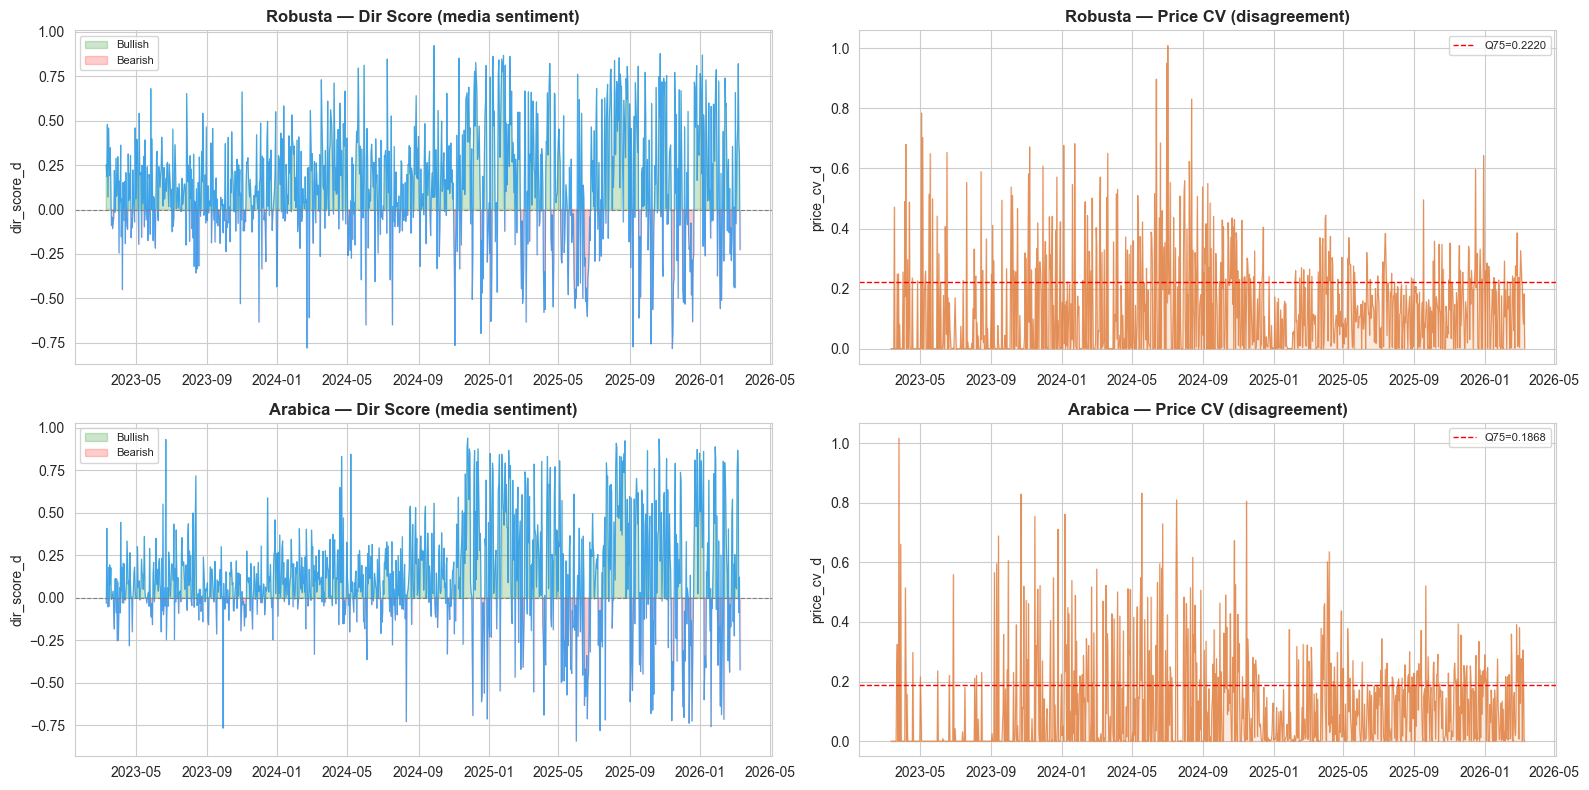

✅ Lưu output/phase1/01_features_timeline.png


In [11]:
# ── 6a. Dir score và price_cv theo thời gian ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for row_idx, (target, daily_df) in enumerate([
    ('Robusta', robusta_daily), ('Arabica', arabica_daily)
]):
    sub = daily_df.sort_values('date')

    # Dir score
    ax = axes[row_idx][0]
    ax.plot(sub['date'], sub['dir_score_d'], linewidth=0.8, color='#2196F3', alpha=0.8)
    ax.fill_between(sub['date'], sub['dir_score_d'], 0,
                    where=sub['dir_score_d'] > 0, alpha=0.2, color='green', label='Bullish')
    ax.fill_between(sub['date'], sub['dir_score_d'], 0,
                    where=sub['dir_score_d'] < 0, alpha=0.2, color='red', label='Bearish')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'{target} — Dir Score (media sentiment)', fontweight='bold')
    ax.set_ylabel('dir_score_d')
    ax.legend(fontsize=8)

    # Price CV (disagreement)
    ax = axes[row_idx][1]
    ax.plot(sub['date'], sub['price_cv_d'], linewidth=0.8, color='#E07B39', alpha=0.8)
    q75 = sub['price_cv_d'].quantile(0.75)
    ax.axhline(q75, color='red', linewidth=1, linestyle='--', label=f'Q75={q75:.4f}')
    ax.fill_between(sub['date'], sub['price_cv_d'], alpha=0.15, color='#E07B39')
    ax.set_title(f'{target} — Price CV (disagreement)', fontweight='bold')
    ax.set_ylabel('price_cv_d')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('output/phase1/01_features_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Lưu output/phase1/01_features_timeline.png')

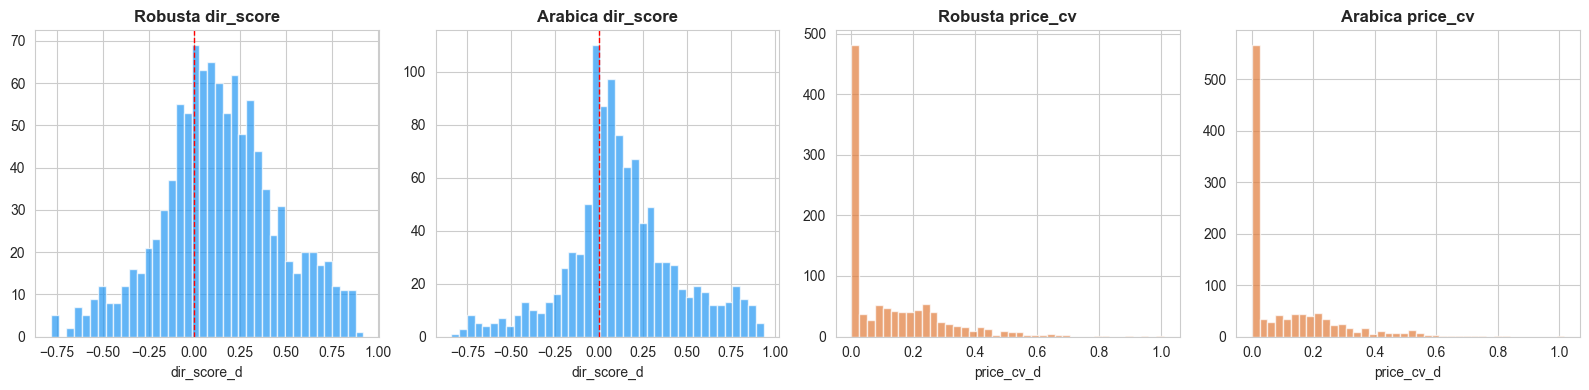

✅ Lưu output/phase1/02_feature_distributions.png


In [12]:
# ── 6b. Distribution của dir_score và price_cv ───────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (label, data) in zip(axes[:2], [
    ('Robusta dir_score', robusta_daily['dir_score_d']),
    ('Arabica dir_score', arabica_daily['dir_score_d']),
]):
    ax.hist(data.dropna(), bins=40, color='#2196F3', alpha=0.7, edgecolor='white')
    ax.axvline(0, color='red', linewidth=1, linestyle='--')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('dir_score_d')

for ax, (label, data) in zip(axes[2:], [
    ('Robusta price_cv', robusta_daily['price_cv_d']),
    ('Arabica price_cv', arabica_daily['price_cv_d']),
]):
    ax.hist(data.dropna(), bins=40, color='#E07B39', alpha=0.7, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('price_cv_d')

plt.tight_layout()
plt.savefig('output/phase1/02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Lưu output/phase1/02_feature_distributions.png')

## 7. Export

In [13]:
def export(daily_df: pd.DataFrame, target: str):
    out = daily_df.drop(columns=['TARGET'], errors='ignore').sort_values('date').reset_index(drop=True)
    path = f'data/04_features/stat_features_{target}.csv'
    out.to_csv(path, index=False)
    print(f'✅ {path}')
    print(f'   {len(out):,} rows × {len(out.columns)} cols')
    sig_cols   = [c for c in out.columns if c.startswith('SIG_')]
    lag_cols   = [c for c in out.columns if 'lag' in c or 'roll' in c]
    base_cols  = [c for c in out.columns if c not in sig_cols + lag_cols + ['date']]
    print(f'   Base: {len(base_cols)} | Lag/roll: {len(lag_cols)} | Signal: {len(sig_cols)}')
    return out

rob_out = export(robusta_daily, 'robusta')
ara_out = export(arabica_daily, 'arabica')

print('\n── Cột feature cuối cùng ──')
for c in rob_out.columns:
    print(f'  {c}')

✅ data/04_features/stat_features_robusta.csv
   1,071 rows × 55 cols
   Base: 15 | Lag/roll: 27 | Signal: 12
✅ data/04_features/stat_features_arabica.csv
   1,077 rows × 55 cols
   Base: 15 | Lag/roll: 27 | Signal: 12

── Cột feature cuối cùng ──
  date
  n_articles_d
  n_sources_d
  pct_has_price_d
  pct_noise_d
  price_median_d
  price_cv_d
  price_range_d
  avg_change_d
  dir_score_d
  title_tang_pct_d
  title_giam_pct_d
  dir_entropy_d
  kw_tang_d
  kw_giam_d
  kw_stable_d
  dir_score_d_lag1
  dir_score_d_lag2
  dir_score_d_lag3
  title_tang_pct_d_lag1
  title_tang_pct_d_lag2
  title_tang_pct_d_lag3
  title_giam_pct_d_lag1
  title_giam_pct_d_lag2
  title_giam_pct_d_lag3
  price_cv_d_lag1
  price_cv_d_lag2
  price_cv_d_lag3
  price_range_d_lag1
  price_range_d_lag2
  price_range_d_lag3
  dir_entropy_d_lag1
  dir_entropy_d_lag2
  dir_entropy_d_lag3
  n_articles_d_lag1
  n_articles_d_lag2
  n_articles_d_lag3
  n_sources_d_lag1
  n_sources_d_lag2
  n_sources_d_lag3
  dir_score_d_roll3


In [14]:
# ── Quick sanity check: so sánh 1 tuần cụ thể ────────────────
print('=== Sanity check — Robusta 7 ngày gần nhất ===')
check_cols = ['date', 'n_articles_d', 'n_sources_d',
              'title_tang_pct_d', 'title_giam_pct_d',
              'dir_score_d', 'price_cv_d', 'price_median_d']
print(rob_out[check_cols].tail(7).to_string(index=False))

=== Sanity check — Robusta 7 ngày gần nhất ===
      date  n_articles_d  n_sources_d  title_tang_pct_d  title_giam_pct_d  dir_score_d  price_cv_d  price_median_d
2026-03-04           6.0          6.0            0.1667            0.3333      -0.0790    0.326320         95100.0
2026-03-06           4.0          4.0            0.5000            0.0000       0.3756    0.221503         83000.0
2026-03-07           6.0          6.0            0.6667            0.1667       0.4520    0.210113        111133.3
2026-03-08           3.0          3.0            1.0000            0.0000       0.8210    0.111565        102983.3
2026-03-09           6.0          6.0            0.5000            0.1667       0.3862    0.082013         99800.0
2026-03-10           7.0          7.0            0.4286            0.1429       0.3039    0.182485        103621.4
2026-03-11           6.0          6.0            0.1667            0.5000      -0.2260    0.001475         95900.0
